In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestRegressor, 
                               GradientBoostingRegressor,
                               AdaBoostRegressor)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                              r2_score, mean_absolute_percentage_error)
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
df = pd.read_csv('../data/climate_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year
df['Day_of_Year'] = df['Date'].dt.dayofyear

print(f"📊 Dataset: {df.shape}")
df.head()

📊 Dataset: (1825, 13)


,Date,Temperature,Humidity,Pressure,Wind_Speed,Rainfall,CO2_Level,Visibility,Cloud_Cover,Month,Day,Year,Day_of_Year
0,2019-01-01,16.71,58.96,1016.24,27.18,0.08,410.28,9.02,35.48,1,1,2019,1
1,2019-01-02,13.68,54.97,1008.38,0.00,0.17,410.95,4.97,57.86,1,2,2019,2
2,2019-01-03,12.58,46.91,1020.33,13.19,0.11,412.56,7.79,53.06,1,3,2019,3
3,2019-01-04,13.80,55.37,1017.74,17.33,0.29,409.36,6.97,23.56,1,4,2019,4
4,2019-01-05,17.86,49.51,1014.04,0.00,0.40,410.22,8.76,24.77,1,5,2019,5


In [3]:
feature_columns = ['Humidity', 'Pressure', 'Wind_Speed', 
                   'CO2_Level', 'Rainfall', 'Cloud_Cover',
                   'Month', 'Day', 'Year', 'Day_of_Year']

X = df[feature_columns]
y = df['Temperature']

print(f"📌 Features ({len(feature_columns)}): {feature_columns}")
print(f"🎯 Target: Temperature")
print(f"📊 X: {X.shape}, y: {y.shape}")


📌 Features (10): ['Humidity', 'Pressure', 'Wind_Speed', 'CO2_Level', 'Rainfall', 'Cloud_Cover', 'Month', 'Day', 'Year', 'Day_of_Year']
🎯 Target: Temperature
📊 X: (1825, 10), y: (1825,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🏋️ Training: {X_train.shape}")
print(f"🧪 Testing:  {X_test.shape}")

🏋️ Training: (1460, 10)
🧪 Testing:  (365, 10)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Features scaled!")

✅ Features scaled!


In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}

results = {}

print("🔄 Training models...\n")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE%':>8}")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    results[name] = {
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 2),
        'model': model
    }
    
    print(f"{name:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {mape:>7.2f}%")

🔄 Training models...

Model                          MAE     RMSE       R²    MAPE%
Linear Regression           5.4108   6.6242   0.2675   24.56%
Ridge Regression            6.1770   7.3589   0.0960   28.83%
Lasso Regression            6.2284   7.4102   0.0833   29.13%
Decision Tree               3.6791   4.6408   0.6405   16.24%
Random Forest               2.7195   3.3555   0.8120   12.02%
Gradient Boosting           2.7058   3.3207   0.8159   12.06%
AdaBoost                    2.7451   3.3994   0.8071   12.27%


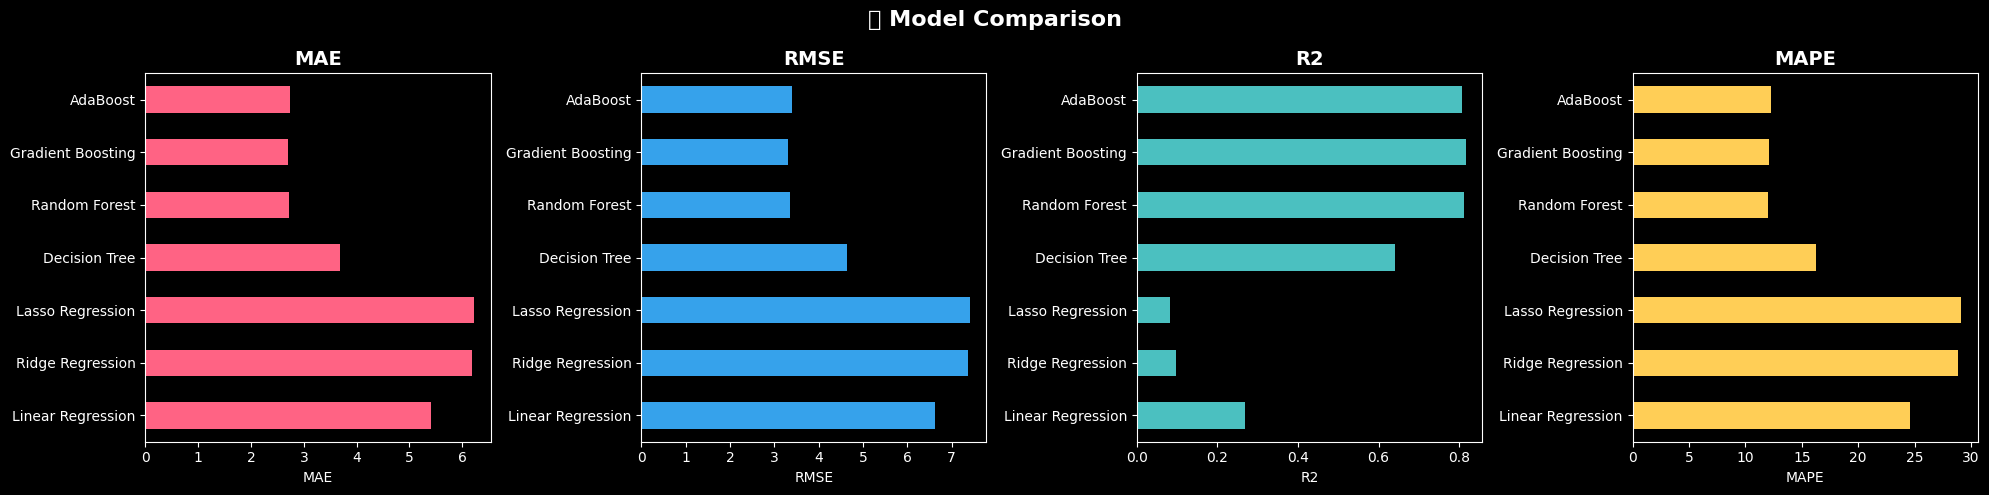

In [7]:
results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'model'} 
    for name, vals in results.items()
}).T

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
colors_list = ['#FF6384', '#36A2EB', '#4BC0C0', '#FFCE56']

for i, (metric, color) in enumerate(zip(metrics, colors_list)):
    results_df[metric].plot(kind='barh', ax=axes[i], color=color)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xlabel(metric)

plt.suptitle('📊 Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
best_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_name]['model']

print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   R² Score: {results[best_name]['R2']}")
print(f"   MAE: {results[best_name]['MAE']}")
print(f"   RMSE: {results[best_name]['RMSE']}")


🏆 BEST MODEL: Gradient Boosting
   R² Score: 0.8159
   MAE: 2.7058
   RMSE: 3.3207


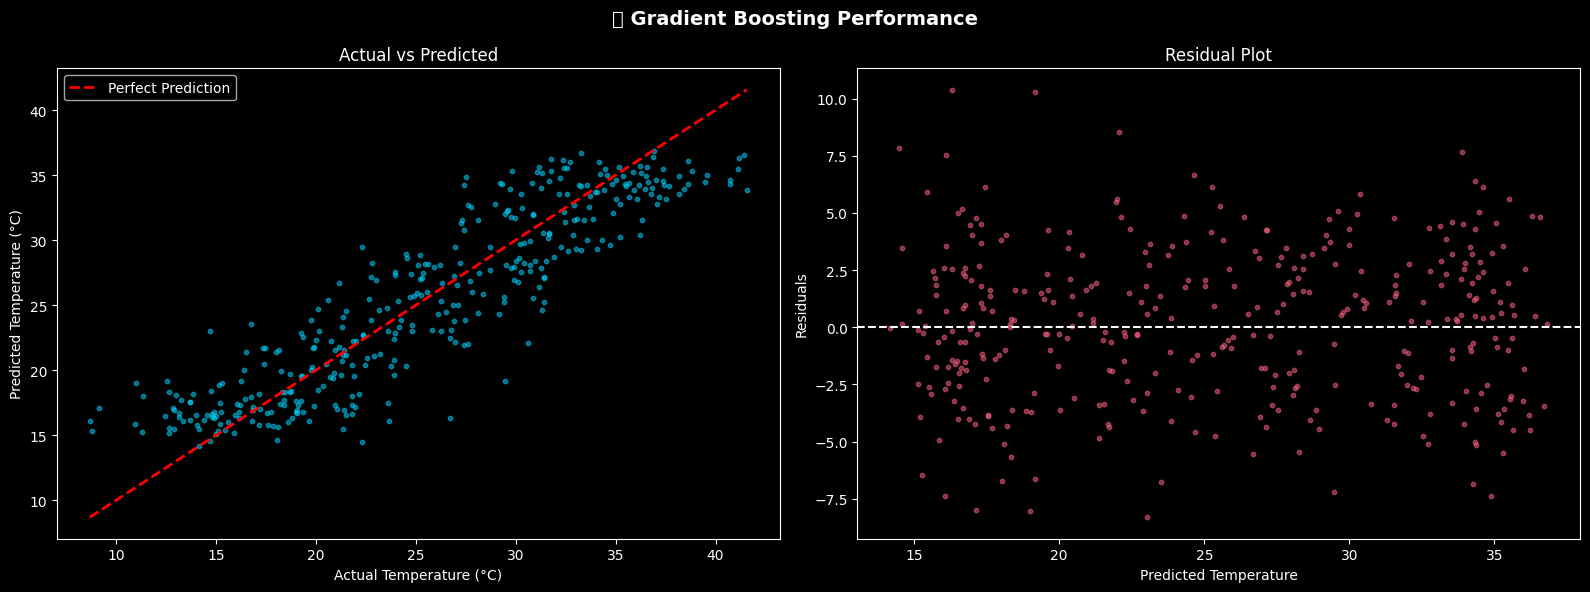

In [9]:
y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='#00d2ff', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color='#FF6384', s=10)
axes[1].axhline(y=0, color='white', linestyle='--')
axes[1].set_xlabel('Predicted Temperature')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.suptitle(f'📈 {best_name} Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

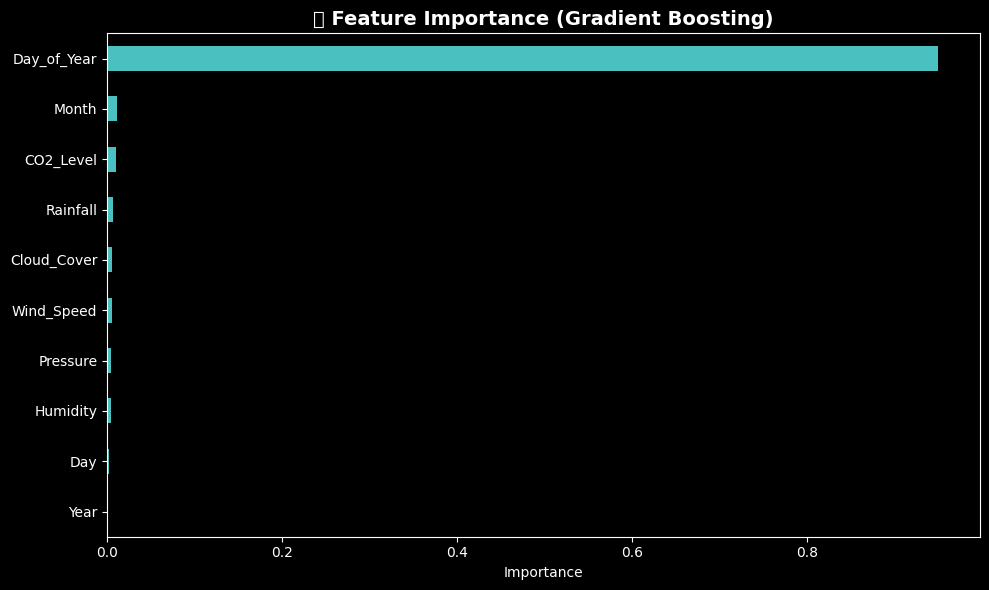

In [10]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_columns
    ).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh', color='#4BC0C0')
    plt.title(f'🔍 Feature Importance ({best_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

In [11]:
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, 
                            cv=5, scoring='r2')
print(f"\n📊 5-Fold Cross Validation ({best_name}):")
print(f"   Scores: {cv_scores.round(4)}")
print(f"   Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


📊 5-Fold Cross Validation (Gradient Boosting):
   Scores: [0.8361 0.8493 0.8433 0.8454 0.8243]
   Mean R²: 0.8397 ± 0.0088


In [12]:
with open('../models/weather_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature columns for webapp
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("\n✅ Saved: models/weather_model.pkl")
print("✅ Saved: models/scaler.pkl")
print("✅ Saved: models/features.pkl")


✅ Saved: models/weather_model.pkl
✅ Saved: models/scaler.pkl
✅ Saved: models/features.pkl


In [13]:
with open('../models/weather_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('../models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test prediction
sample = np.array([[65, 1013, 12, 415, 0, 50, 6, 15, 2024, 166]])
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)
print(f"\n🌡️ Test Prediction: {pred[0]:.2f}°C")
print("✅ Model working correctly!")


🌡️ Test Prediction: 36.09°C
✅ Model working correctly!
